In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
# List all files in your Drive root
!ls "/content/drive/My Drive/"

#

'Colab Notebooks'   model   vitamin_deficiency.zip


In [ ]:
import zipfile
import os

# Path to the zip file in your Drive
zip_path = "/content/drive/My Drive/vitamin_deficiency.zip"

# Path where you want to extract the dataset
extract_path = "/content/vitamin_deficiency"

# Create extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)


Dataset extracted to: /content/vitamin_deficiency


In [ ]:
import os
import shutil

# Current path with double folder
old_base = '/content/vitamin_deficiency/vitamin_deficiency'
new_base = '/content/vitamin_deficiency'

# List all class folders
classes = os.listdir(old_base)
for cls in classes:
    old_cls_path = os.path.join(old_base, cls)
    new_cls_path = os.path.join(new_base, cls)

    # Move the whole folder if it doesn't exist already
    if not os.path.exists(new_cls_path):
        shutil.move(old_cls_path, new_base)

# Optional: remove empty old folder
if os.path.exists(old_base):
    os.rmdir(old_base)

print("Dataset structure flattened successfully!")


Dataset structure flattened successfully!


In [ ]:
data_dir = '/content/vitamin_deficiency'


In [ ]:
import os
os.listdir('/content/vitamin_deficiency')


['angular_cheilitis',
 'glossitis',
 'healthy_mouth',
 'healthy_tongue',
 'phrynoderma',
 'bitot_spots',
 'healthy_lips',
 'ulcer',
 'healthy_elbows',
 'healthy_eye']

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import os

# ---------------- SETTINGS ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = '/content/vitamin_deficiency'
num_classes = 10
batch_size = 32
epochs = 25
learning_rate = 1e-3
weight_decay = 1e-4
patience = 4

class_names = ['angular_cheilitis', 'bitot_spots', 'glossitis', 'healthy_elbows',
               'healthy_eye', 'healthy_lips', 'healthy_mouth', 'healthy_tongue',
               'phrynoderma', 'ulcer']

# ---------------- TRANSFORMS ----------------
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---------------- DATASETS ----------------
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ---------------- MODEL ----------------
resnet_model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(resnet_model.fc.in_features, num_classes)
)
resnet_model = resnet_model.to(device)

# ---------------- LOSS & OPTIMIZER ----------------
# Compute class weights
class_counts = [len(os.listdir(os.path.join(data_dir, 'train', cls))) for cls in class_names]
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(resnet_model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# ---------------- TRAINING LOOP ----------------
best_val_loss = float('inf')
counter = 0
drive_model_path = '/content/drive/MyDrive/model'
os.makedirs(drive_model_path, exist_ok=True)

for epoch in range(epochs):
    # Train
    resnet_model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(train_loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_loss = total_loss / len(train_loader)

    # Validation
    resnet_model.eval()
    val_loss_total, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet_model(images)
            loss = criterion(outputs, labels)
            val_loss_total += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total
    val_loss = val_loss_total / len(test_loader)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Early stopping & save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(resnet_model.state_dict(), os.path.join(drive_model_path, 'best_model34.pth'))
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

    scheduler.step(val_loss)

print("Training complete. Best model saved to Google Drive!")

# ---------------- TESTING ----------------
resnet_model.load_state_dict(torch.load(os.path.join(drive_model_path, 'best_model34.pth'), map_location=device))
resnet_model.eval()

correct, total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 213MB/s]


Epoch 1/25 | Train Loss: 1.1938 | Train Acc: 60.02% | Val Loss: 1.4653 | Val Acc: 53.98% | LR: 0.001000


Epoch 2/25 | Train Loss: 0.8302 | Train Acc: 71.53% | Val Loss: 1.4475 | Val Acc: 61.06% | LR: 0.001000


Epoch 3/25 | Train Loss: 0.7227 | Train Acc: 75.65% | Val Loss: 0.8624 | Val Acc: 80.53% | LR: 0.001000


...

Epoch 15/25 | Train Loss: 0.2244 | Train Acc: 93.72% | Val Loss: 0.3905 | Val Acc: 90.27% | LR: 0.000250


Epoch 16/25 | Train Loss: 0.2057 | Train Acc: 93.22% | Val Loss: 0.4431 | Val Acc: 88.94% | LR: 0.000250


Epoch 17/25 | Train Loss: 0.2263 | Train Acc: 92.41% | Val Loss: 0.5817 | Val Acc: 88.05% | LR: 0.000250


Epoch 18/25 | Train Loss: 0.2047 | Train Acc: 92.99% | Val Loss: 0.5173 | Val Acc: 89.82% | LR: 0.000250


Epoch 19/25 | Train Loss: 0.1678 | Train Acc: 93.88% | Val Loss: 0.4991 | Val Acc: 90.71% | LR: 0.000125
Early stopping triggered
Training complete. Best model saved to Google Drive!
Test Accuracy: 90.27%


In [ ]:
import os

for root, dirs, files in os.walk('/content', topdown=True):
    for file in files:
        if file.endswith('.pth') or file.endswith('.pt'):
            print(os.path.join(root, file))


/content/drive/MyDrive/model/best_model34.pth


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

model_path = "/content/drive/MyDrive/model/best_model34.pth"

# Build SAME architecture used during training
model = models.resnet34(weights=None)
num_ftrs = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 10)    # 10 classes
)

# Load weights
state = torch.load(model_path, map_location="cuda")
model.load_state_dict(state)

model = model.to("cuda")
model.eval()

print("Model loaded successfully!")


Model loaded successfully!


**Confusion Matrix( After Initial Training)**


<Figure size 1200x1000 with 0 Axes>

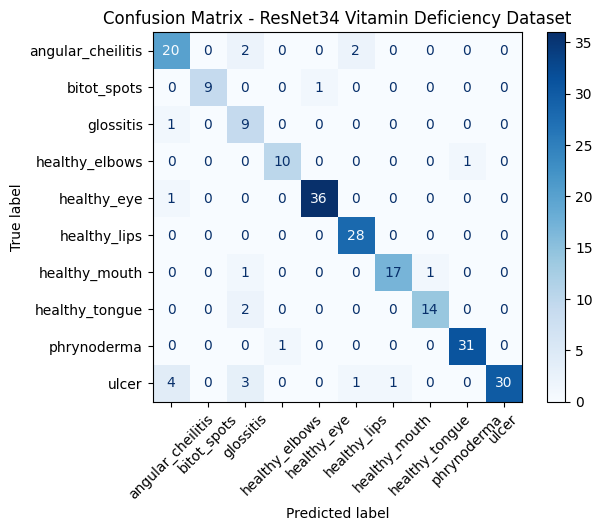

In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ----- CLASS NAMES -----
class_names = [
    'angular_cheilitis',
    'bitot_spots',
    'glossitis',
    'healthy_elbows',
    'healthy_eye',
    'healthy_lips',
    'healthy_mouth',
    'healthy_tongue',
    'phrynoderma',
    'ulcer'
]

# ----- COLLECT PREDICTIONS -----
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to("cuda"), labels.to("cuda")
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ----- CONFUSION MATRIX -----
cm = confusion_matrix(all_labels, all_preds)

# ----- PLOT -----
plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - ResNet34 Vitamin Deficiency Dataset")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# ----- TEXT CLASSIFICATION REPORT -----
report = classification_report(all_labels, all_preds, target_names=class_names)
print("===== Classification Report =====\n")
print(report)


===== Classification Report =====

                   precision    recall  f1-score   support

angular_cheilitis       0.77      0.83      0.80        24
      bitot_spots       1.00      0.90      0.95        10
        glossitis       0.53      0.90      0.67        10
   healthy_elbows       0.91      0.91      0.91        11
      healthy_eye       0.97      0.97      0.97        37
     healthy_lips       0.90      1.00      0.95        28
    healthy_mouth       0.94      0.89      0.92        19
   healthy_tongue       0.93      0.88      0.90        16
      phrynoderma       0.97      0.97      0.97        32
            ulcer       1.00      0.77      0.87        39

         accuracy                           0.90       226
        macro avg       0.89      0.90      0.89       226
     weighted avg       0.92      0.90      0.91       226



In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image

model_path = "/content/drive/MyDrive/model/best_model34.pth"

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load base model
from torchvision import models
model = models.resnet34(pretrained=False)

# Replace classifier exactly like training
import torch.nn as nn
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(512, 10)
)

# Load weights
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

print("Model ready!")


Model ready!


In [ ]:
class_names = [
    'angular_cheilitis', 'bitot_spots', 'glossitis', 'healthy_elbows',
    'healthy_eye', 'healthy_lips', 'healthy_mouth', 'healthy_tongue',
    'phrynoderma', 'ulcer'
]


In [ ]:
from google.colab import files
from PIL import Image
import torchvision.transforms as transforms
import torch

# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- UPLOAD IMAGE ----------------
uploaded = files.upload()  # upload unnamed.jpg
image_path = list(uploaded.keys())[0]  # get uploaded filename

# ---------------- TRANSFORM ----------------
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

image = Image.open(image_path).convert("RGB")
image = transform(image).unsqueeze(0).to(device)  # add batch dimension

# ---------------- CLASS NAMES ----------------
class_names = ['angular_cheilitis', 'bitot_spots', 'glossitis', 'healthy_elbows',
               'healthy_eye', 'healthy_lips', 'healthy_mouth', 'healthy_tongue',
               'phrynoderma', 'ulcer']

# ---------------- LOAD MODEL ----------------
model_path = "/content/drive/MyDrive/model/best_model34.pth"
resnet_model.load_state_dict(torch.load(model_path, map_location=device))
resnet_model.to(device)
resnet_model.eval()

# ---------------- PREDICTION ----------------
with torch.no_grad():
    outputs = resnet_model(image)
    _, predicted = torch.max(outputs, 1)
    predicted_class = class_names[predicted.item()]

print(f"Predicted class: {predicted_class}")


Saving IMG_7242.jpeg to IMG_7242.jpeg
Predicted class: healthy_eye


**Initial Training Done**


In [ ]:
train_dir = "/content/vitamin_deficiency/train"
test_dir = "/content/vitamin_deficiency/test"

weak_classes = ['angular_cheilitis', 'glossitis']

train_dataset = TargetedAugDataset(train_dir, transform=train_transform, weak_classes=weak_classes)
test_dataset = TargetedAugDataset(test_dir, transform=val_transform)  # no augmentation for test

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Loaded 2580 images from /content/vitamin_deficiency/train
Loaded 226 images from /content/vitamin_deficiency/test
Train samples: 2580
Test samples: 226


In [ ]:
import os
import shutil

data_dir = '/content/vitamin_deficiency'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

classes = [cls for cls in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, cls)) and cls not in ['train', 'test']]

for cls in classes:
    cls_path = os.path.join(data_dir, cls)

    # Move train images
    cls_train_src = os.path.join(cls_path, 'train')
    cls_train_dst = os.path.join(train_dir, cls)
    if os.path.exists(cls_train_src):
        os.makedirs(cls_train_dst, exist_ok=True)
        shutil.move(cls_train_src, cls_train_dst)

    # Move test images
    cls_test_src = os.path.join(cls_path, 'test')
    cls_test_dst = os.path.join(test_dir, cls)
    if os.path.exists(cls_test_src):
        os.makedirs(cls_test_dst, exist_ok=True)
        shutil.move(cls_test_src, cls_test_dst)


In [ ]:
import os
import random
import shutil

data_dir = '/content/vitamin_deficiency'
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')

os.makedirs(val_dir, exist_ok=True)

# Loop over each class
classes = os.listdir(train_dir)
for cls in classes:
    cls_train_path = os.path.join(train_dir, cls)
    cls_val_path = os.path.join(val_dir, cls)
    os.makedirs(cls_val_path, exist_ok=True)

    # Get all images
    images = os.listdir(cls_train_path)
    random.shuffle(images)

    # 15% for validation
    val_count = int(0.15 * len(images))
    val_images = images[:val_count]

    # Move images to val folder
    for img in val_images:
        shutil.move(os.path.join(cls_train_path, img), os.path.join(cls_val_path, img))

print("Train/Validation split done. Validation images are untouched (no augmentation).")


Train/Validation split done. Validation images are untouched (no augmentation).


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ---------------- TRANSFORMS ----------------
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---------------- DATASETS ----------------
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_transform)

# ---------------- DATALOADERS ----------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")


Train samples: 2185, Val samples: 381, Test samples: 225


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from PIL import Image
import os
import random
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# ---------------- SETTINGS ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "/content/vitamin_deficiency"
num_classes = 10
batch_size = 32
epochs = 25
patience = 4
learning_rate = 1e-3
weight_decay = 1e-4

class_names = ['angular_cheilitis', 'bitot_spots', 'glossitis', 'healthy_elbows',
               'healthy_eye', 'healthy_lips', 'healthy_mouth', 'healthy_tongue',
               'phrynoderma', 'ulcer']

weak_classes = ['angular_cheilitis', 'glossitis', 'ulcer']

# ---------------- TRANSFORMS ----------------
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ---------------- CUSTOM DATASET ----------------
class TargetedAugDataset(Dataset):
    def __init__(self, root_dir, transform=None, weak_classes=None):
        self.transform = transform
        self.weak_classes = weak_classes or []
        self.samples = []
        self.class_to_idx = {cls: i for i, cls in enumerate(sorted(os.listdir(root_dir)))}

        for cls_name in self.class_to_idx.keys():
            cls_path = os.path.join(root_dir, cls_name)
            for img_name in os.listdir(cls_path):
                self.samples.append((os.path.join(cls_path, img_name), self.class_to_idx[cls_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Extra augmentation for weak classes
        if list(self.class_to_idx.keys())[label] in self.weak_classes:
            if random.random() < 0.5:
                image = transforms.functional.hflip(image)
            if random.random() < 0.5:
                image = transforms.functional.adjust_brightness(image, 1 + (random.random()-0.5)*0.4)
            if random.random() < 0.5:
                image = transforms.functional.adjust_contrast(image, 1 + (random.random()-0.5)*0.4)

        return image, label

# ---------------- DATASETS ----------------
train_dataset = TargetedAugDataset(os.path.join(data_dir, 'train'), transform=train_transform, weak_classes=weak_classes)
val_dataset   = TargetedAugDataset(os.path.join(data_dir, 'val'), transform=val_transform)
test_dataset  = TargetedAugDataset(os.path.join(data_dir, 'test'), transform=val_transform)

# ---------------- CLASS WEIGHTS & SAMPLER ----------------
def compute_class_weights(dataset):
    counts = [0]*num_classes
    for _, label in dataset.samples:
        counts[label] += 1
    weights = 1./torch.tensor(counts, dtype=torch.float)
    sample_weights = [weights[label] for _, label in dataset.samples]
    return sample_weights

sample_weights = compute_class_weights(train_dataset)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# ---------------- DATALOADERS ----------------
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ---------------- MODEL ----------------
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, num_classes)
)
model = model.to(device)

# ---------------- LOSS & OPTIMIZER ----------------
class_counts = [sum([1 for _, label in train_dataset.samples if label==i]) for i in range(num_classes)]
class_weights = 1./torch.tensor(class_counts, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# ---------------- TRAINING LOOP ----------------
best_val_loss = float('inf')
counter = 0

for epoch in range(epochs):
    # Train
    model.train()
    total_loss, correct, total = 0,0,0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs,1)
        correct += (preds==labels).sum().item()
        total += labels.size(0)
    train_acc = 100*correct/total
    train_loss = total_loss/len(train_loader)

    # Validate
    model.eval()
    val_loss_total, val_correct, val_total = 0,0,0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_total += loss.item()
            _, preds = torch.max(outputs,1)
            val_correct += (preds==labels).sum().item()
            val_total += labels.size(0)
    val_acc = 100*val_correct/val_total
    val_loss = val_loss_total/len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Early stopping & save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/model/best_model34.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

    scheduler.step(val_loss)

# ---------------- TEST ----------------
model.load_state_dict(torch.load('/content/drive/MyDrive/model/best_model34.pth'))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
report = classification_report(all_labels, all_preds, target_names=class_names)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:01<00:00, 66.9MB/s]


Epoch 1/25 | Train Loss: 1.1863 | Train Acc: 59.41% | Val Loss: 1.9495 | Val Acc: 46.19%
Epoch 2/25 | Train Loss: 0.8751 | Train Acc: 67.51% | Val Loss: 0.7533 | Val Acc: 74.54%
Epoch 3/25 | Train Loss: 0.7309 | Train Acc: 73.78% | Val Loss: 1.2642 | Val Acc: 62.20%
Epoch 4/25 | Train Loss: 0.6477 | Train Acc: 77.80% | Val Loss: 0.6966 | Val Acc: 75.59%
Epoch 5/25 | Train Loss: 0.6506 | Train Acc: 75.29% | Val Loss: 0.8321 | Val Acc: 71.39%
Epoch 6/25 | Train Loss: 0.5366 | Train Acc: 80.69% | Val Loss: 0.4883 | Val Acc: 85.04%
Epoch 7/25 | Train Loss: 0.5423 | Train Acc: 81.24% | Val Loss: 0.6337 | Val Acc: 80.05%
Epoch 8/25 | Train Loss: 0.5658 | Train Acc: 79.45% | Val Loss: 0.6087 | Val Acc: 77.95%
Epoch 9/25 | Train Loss: 0.5010 | Train Acc: 81.14% | Val Loss: 0.2908 | Val Acc: 89.76%
Epoch 10/25 | Train Loss: 0.4196 | Train Acc: 85.17% | Val Loss: 0.4940 | Val Acc: 83.20%
Epoch 11/25 | Train Loss: 0.4329 | Train Acc: 84.62% | Val Loss: 0.4954 | Val Acc: 85.04%
Epoch 12/25 | Train

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from tqdm import tqdm
from PIL import Image
import os
import random
import numpy as np

# ---------------- SETTINGS ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = '/content/vitamin_deficiency'  # root folder containing 'train', 'val', 'test'
batch_size = 32
epochs = 10  # short retraining
learning_rate = 1e-4
weight_decay = 1e-4

class_names = ['angular_cheilitis', 'bitot_spots', 'glossitis', 'healthy_elbows',
               'healthy_eye', 'healthy_lips', 'healthy_mouth', 'healthy_tongue',
               'phrynoderma', 'ulcer']

weak_classes = ['angular_cheilitis', 'glossitis', 'ulcer']

# ---------------- TRANSFORMS ----------------
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---------------- DATASET ----------------
class TargetedAugDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None, weak_classes=None):
        self.transform = transform
        self.weak_classes = weak_classes or []
        self.samples = []
        self.classes = sorted(entry.name for entry in os.scandir(root_dir) if entry.is_dir())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            for img_name in os.listdir(cls_path):
                self.samples.append((os.path.join(cls_path, img_name), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Extra augmentation for weak classes
        if self.classes[label] in self.weak_classes:
            if random.random() < 0.5:
                image = transforms.functional.hflip(image)
            if random.random() < 0.5:
                image = transforms.functional.adjust_brightness(image, 1 + (random.random() - 0.5) * 0.4)
            if random.random() < 0.5:
                image = transforms.functional.adjust_contrast(image, 1 + (random.random() - 0.5) * 0.4)

        return image, label

# ---------------- DATALOADERS ----------------
train_dataset = TargetedAugDataset(os.path.join(data_dir, 'train'), transform=train_transform, weak_classes=weak_classes)
val_dataset = TargetedAugDataset(os.path.join(data_dir, 'val'), transform=val_transform)
test_dataset = TargetedAugDataset(os.path.join(data_dir, 'test'), transform=val_transform)

# Compute class weights for weighted loss
class_counts = np.zeros(len(class_names))
for _, label in train_dataset:
    class_counts[label] += 1
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights.to(device)

# Weighted sampler for oversampling weak classes
sample_weights = [class_weights[label] for _, label in train_dataset]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ---------------- MODEL ----------------
model = models.resnet34(weights=None)  # we will load previous weights
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, len(class_names))
)

# Load previous best weights
model_path = '/content/drive/MyDrive/model/best_model34.pth'
state_dict = torch.load(model_path, map_location=device)

# Adjust state_dict keys if needed
from collections import OrderedDict
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    if k.startswith('fc.1'):
        new_key = 'fc.1.' + k.split('.')[-1]
    else:
        new_key = k
    new_state_dict[new_key] = v

try:
    model.load_state_dict(state_dict)
except RuntimeError:
    model.load_state_dict(new_state_dict)

model = model.to(device)

# ---------------- LOSS & OPTIMIZER ----------------
# Focal loss to focus on hard examples
class FocalLoss(nn.Module):
    def __init__(self, gamma=2, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.ce = nn.CrossEntropyLoss(weight=weight)

    def forward(self, input, target):
        logpt = -self.ce(input, target)
        pt = torch.exp(logpt)
        loss = -((1 - pt) ** self.gamma) * logpt
        return loss.mean()

criterion = FocalLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# ---------------- TRAINING LOOP ----------------
best_val_loss = float('inf')
patience = 4
counter = 0

for epoch in range(epochs):
    # Training
    model.train()
    total_loss, correct, total = 0, 0, 0
    loop = tqdm(train_loader, leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
        loop.set_postfix(loss=loss.item())

    train_loss = total_loss / len(train_loader)
    train_acc = 100 * correct / total

    # Validation
    model.eval()
    val_loss_total, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_total += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_total / len(val_loader)
    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/model/resnet_best_model34_retrained.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

    scheduler.step(val_loss)

print("Retraining complete. Best model saved!")


Epoch 1/10 | Train Loss: 0.0187 | Train Acc: 91.90% | Val Loss: 0.0141 | Val Acc: 96.33% | LR: 0.000100


Epoch 2/10 | Train Loss: 0.0102 | Train Acc: 92.36% | Val Loss: 0.0184 | Val Acc: 96.06% | LR: 0.000100


Epoch 3/10 | Train Loss: 0.0069 | Train Acc: 94.23% | Val Loss: 0.0406 | Val Acc: 95.80% | LR: 0.000100


Epoch 4/10 | Train Loss: 0.0099 | Train Acc: 92.68% | Val Loss: 0.0183 | Val Acc: 95.54% | LR: 0.000100


Epoch 5/10 | Train Loss: 0.0108 | Train Acc: 92.81% | Val Loss: 0.0314 | Val Acc: 94.75% | LR: 0.000050
Early stopping triggered
Retraining complete. Best model saved!


In [ ]:
import torch
from torchvision import models
import torch.nn as nn

num_classes = 10

# Load ResNet34 base
model = models.resnet34(weights=None)

# Use the same fc as training (Dropout + Linear)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, num_classes)
)

# Load retrained weights
model.load_state_dict(torch.load('/content/drive/MyDrive/model/resnet_best_model34_retrained.pth', map_location='cuda'))
model = model.to('cuda')
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
import torch
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# ---------------- SETTINGS ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 10
data_dir = '/content/vitamin_deficiency/test'  # path to test folder
class_names = ['angular_cheilitis', 'bitot_spots', 'glossitis', 'healthy_elbows',
               'healthy_eye', 'healthy_lips', 'healthy_mouth', 'healthy_tongue',
               'phrynoderma', 'ulcer']

# ---------------- TRANSFORMS ----------------
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---------------- DATASET & LOADER ----------------
test_dataset = datasets.ImageFolder(data_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ---------------- MODEL ----------------
model = models.resnet34(weights=None)
model.fc = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(model.fc.in_features, num_classes)
)
model.load_state_dict(torch.load('/content/drive/MyDrive/model/resnet_best_model34_retrained.pth', map_location=device))
model = model.to(device)
model.eval()

# ---------------- EVALUATION ----------------
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Accuracy
accuracy = (all_preds == all_labels).sum() / len(all_labels)
print(f"Test Accuracy: {accuracy*100:.2f}%\n")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm, "\n")

# Classification Report
report = classification_report(all_labels, all_preds, target_names=class_names)
print("Classification Report:")
print(report)


Test Accuracy: 89.78%

Confusion Matrix:
[[15  0  1  0  0  4  1  0  0  2]
 [ 0  9  0  0  1  0  0  0  0  0]
 [ 1  0  6  0  0  0  0  1  0  2]
 [ 0  0  0 10  0  0  0  0  1  0]
 [ 0  0  0  0 37  0  0  0  0  0]
 [ 0  0  0  0  0 28  0  0  0  0]
 [ 0  0  0  0  0  0 18  1  0  0]
 [ 0  0  0  0  0  0  0 16  0  0]
 [ 0  0  0  1  0  1  0  0 30  0]
 [ 0  0  2  0  1  1  2  0  0 33]] 

Classification Report:
                   precision    recall  f1-score   support

angular_cheilitis       0.94      0.65      0.77        23
      bitot_spots       1.00      0.90      0.95        10
        glossitis       0.67      0.60      0.63        10
   healthy_elbows       0.91      0.91      0.91        11
      healthy_eye       0.95      1.00      0.97        37
     healthy_lips       0.82      1.00      0.90        28
    healthy_mouth       0.86      0.95      0.90        19
   healthy_tongue       0.89      1.00      0.94        16
      phrynoderma       0.97      0.94      0.95        32
            

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from PIL import Image
import os
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import random

# ---------------- PARAMETERS ----------------
device = "cuda" if torch.cuda.is_available() else "cpu"
data_dir = "/content/vitamin_deficiency"
batch_size = 32
weak_classes = ["angular_cheilitis", "glossitis", "ulcer", "healthy_mouth"]
num_epochs = 10
lr = 1e-4

# ---------------- TARGETED AUGMENTATION DATASET ----------------
class TargetedAugDataset(Dataset):
    def __init__(self, root_dir, transform=None, weak_classes=None):
        self.transform = transform
        self.weak_classes = weak_classes or []
        self.samples = []

        classes = sorted(entry.name for entry in os.scandir(root_dir) if entry.is_dir())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

        for cls_name in classes:
            cls_path = os.path.join(root_dir, cls_name)
            for img_name in os.listdir(cls_path):
                self.samples.append((os.path.join(cls_path, img_name), self.class_to_idx[cls_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Targeted augmentation for weak classes
        cls_name = list(self.class_to_idx.keys())[label]
        if cls_name in self.weak_classes:
            if random.random() < 0.5:
                image = transforms.functional.hflip(image)
            if random.random() < 0.5:
                image = transforms.functional.adjust_brightness(image, 1 + (random.random() - 0.5) * 0.4)
            if random.random() < 0.5:
                image = transforms.functional.adjust_contrast(image, 1 + (random.random() - 0.5) * 0.4)

        return image, label

# ---------------- TRANSFORMS ----------------
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# ---------------- DATASETS ----------------
train_dataset = TargetedAugDataset(os.path.join(data_dir, "train"), transform=train_transform, weak_classes=weak_classes)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_test_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_test_transform)

# ---------------- CLASS WEIGHTS ----------------
class_counts = [0]*len(train_dataset.class_to_idx)
for _, label in train_dataset.samples:
    class_counts[label] += 1

weights_per_class = [1.0 / count for count in class_counts]
samples_weight = [weights_per_class[label] for _, label in train_dataset.samples]
sampler = WeightedRandomSampler(samples_weight, num_samples=len(samples_weight), replacement=True)

# ---------------- DATALOADERS ----------------
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ---------------- MODEL ----------------
model = models.resnet34(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, len(train_dataset.class_to_idx))
)
# Load previous weights
model.load_state_dict(torch.load("/content/drive/MyDrive/model/resnet_best_model34_retrained.pth", map_location=device))
model = model.to(device)

# ---------------- LOSS & OPTIMIZER ----------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# ---------------- TRAIN LOOP ----------------
best_val_loss = np.inf
counter = 0
patience = 3

for epoch in range(num_epochs):
    # --- TRAIN ---
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    # --- VALIDATION ---
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/content/drive/MyDrive/model/resnet_finetuned_targeted.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

# ---------------- TEST EVALUATION ----------------
model.load_state_dict(torch.load("/content/drive/MyDrive/model/resnet_finetuned_targeted.pth", map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
cr = classification_report(all_labels, all_preds, target_names=train_dataset.class_to_idx.keys())

test_acc = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)

print(f"Test Accuracy: {test_acc:.2f}%")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", cr)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1/10 | Train Loss: 0.0699 | Train Acc: 97.99% | Val Loss: 0.0827 | Val Acc: 97.38%
Epoch 2/10 | Train Loss: 0.0358 | Train Acc: 98.86% | Val Loss: 0.1080 | Val Acc: 97.11%
Epoch 3/10 | Train Loss: 0.0294 | Train Acc: 99.13% | Val Loss: 0.0797 | Val Acc: 97.11%
Epoch 4/10 | Train Loss: 0.0178 | Train Acc: 99.50% | Val Loss: 0.0971 | Val Acc: 97.38%
Epoch 5/10 | Train Loss: 0.0172 | Train Acc: 99.41% | Val Loss: 0.0990 | Val Acc: 97.64%
Epoch 6/10 | Train Loss: 0.0144 | Train Acc: 99.68% | Val Loss: 0.0538 | Val Acc: 98.43%
Epoch 7/10 | Train Loss: 0.0105 | Train Acc: 99.68% | Val Loss: 0.0811 | Val Acc: 98.69%
Epoch 8/10 | Train Loss: 0.0104 | Train Acc: 99.82% | Val Loss: 0.0708 | Val Acc: 98.43%
Epoch 9/10 | Train Loss: 0.0073 | Train Acc: 99.86% | Val Loss: 0.0589 | Val Acc: 98.16%
Early stopping triggered
Test Accuracy: 92.00%
Confusion Matrix:
 [[16  0  1  0  0  3  1  0  0  2]
 [ 0  9  0  0  1  0  0  0  0  0]
 [ 1  0  8  0  0  0  0  0  0  1]
 [ 0  0  0 10  0  0  0  0  1  0]
 

In [ ]:
import torch

# Assuming 'model' is your trained model
save_path = '/content/drive/MyDrive/model/finalized_resnet_best_model.pth'
torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")


Model saved to: /content/drive/MyDrive/model/finalized_resnet_best_model.pth


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# -------- DEVICE --------
device = "cuda" if torch.cuda.is_available() else "cpu"

# -------- CLASS NAMES (MUST MATCH TRAIN FOLDER ORDER) --------
IDX_TO_LABEL = {
    0: "angular_cheilitis",
    1: "bitot_spots",
    2: "glossitis",
    3: "healthy_elbows",
    4: "healthy_eye",
    5: "healthy_lips",
    6: "healthy_mouth",
    7: "healthy_tongue",
    8: "phrynoderma",
    9: "ulcer"
    # add remaining if you have more
}

NUM_CLASSES = len(IDX_TO_LABEL)

# -------- LOAD MODEL --------
model = models.resnet34(pretrained=False)

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, NUM_CLASSES)
)

model.load_state_dict(
    torch.load("/content/drive/MyDrive/model/finalized_resnet_best_model.pth",
               map_location=device)
)

model = model.to(device)
model.eval()

print("✅ Model loaded successfully")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded successfully
